In [1]:
import torch
import sys
import time

sys.path.append("/home/hpc/v120bb/v120bb18/UnReflectAnything")
from utilities.visualization import rgb, panelize
from polar_highlighter import PolarHighlighter

if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    curr_device = torch.cuda.current_device()
    device_name = torch.cuda.get_device_name(curr_device)
    print(f"CUDA is available: {num_devices} device(s) detected.")
    print(f"Current device id: {curr_device} - {device_name}")
else:
    print("CUDA is not available")
%load_ext autoreload
%autoreload 2


CUDA is available: 1 device(s) detected.
Current device id: 0 - NVIDIA A100-SXM4-80GB


In [2]:
from main import load_and_process_config
from models import load_best_model_by_run
from dataset import from_config
from utilities import tensor_dict_summarize


config = load_and_process_config("config_test.yaml")
config.RUN = "fine-water-334"
highlighter = PolarHighlighter(width=448, height=448).cuda()
dataset = from_config(config)["test"]
model = load_best_model_by_run(config.RUN).eval().cuda()

DATASET  [14:21:24] Processing 1 datasets: ['SCARED']

DATASET  [14:21:24] Using all scenes except VAL_SCENES for SCARED training

DATASET  [14:21:24]   ✓ Created training dataset for SCARED: 15420 samples (excluding 13 val scenes)

DATASET  [14:21:24]   ✓ Created validation dataset for SCARED: 11323 samples from 13 scenes

DATASET  [14:21:24] === Dataset Creation Summary ===

...

DATASET  [14:21:24] Test:       11323 total samples

INFO     [14:21:24] Found valid run to resume: /anvme/workspace/v120bb18-unreflectanything/results/fine-water-334

INFO     [14:21:24] Latest checkpoint: 
/anvme/workspace/v120bb18-unreflectanything/results/fine-water-334/models/weights_best.pt

INFO     [14:21:24] Latest epoch: 14

MODEL    [14:21:25] Model with class RGBDistillDecomposer created with 98,506,147 parameters

Forward pass on (32, 3, 448, 448) image: 1238ms s/img]


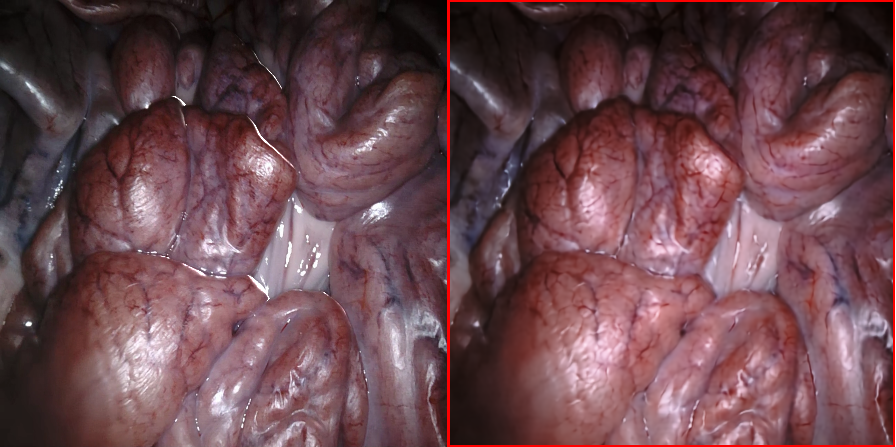

Forward pass on (32, 3, 448, 448) image: 756ms s/img]


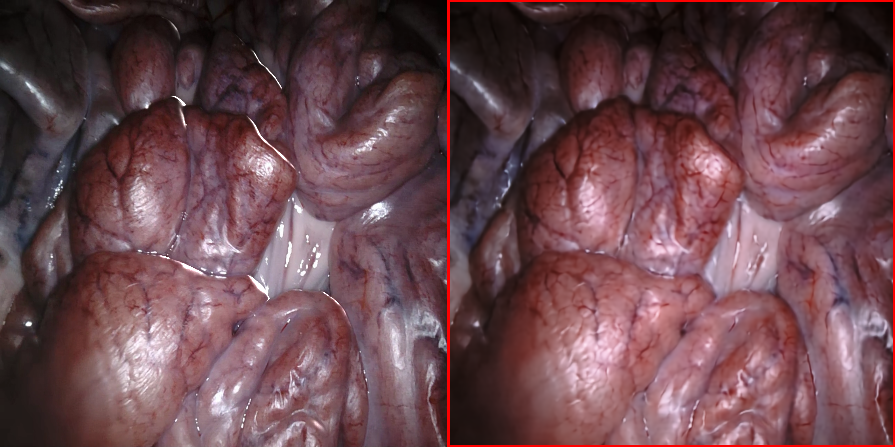

Forward pass on (32, 3, 448, 448) image: 192ms s/img]


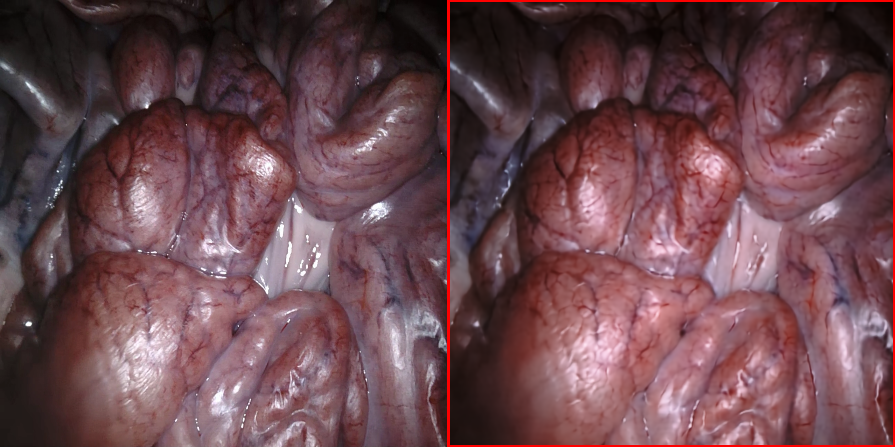

In [ ]:

dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

for batch in dataloader:
    batch = {
        k: v.cuda() if isinstance(v, torch.Tensor) and torch.cuda.is_available() else v
        for k, v in batch.items()
    }
    highlighted = highlighter(
        batch["diffuse"], intrinsic=batch["intrinsics"], shininess=50, ks=5,
    )
    model_input = {"rgb": highlighted["rgb_highlighted"].cuda()}
    with torch.no_grad():
        startt = time.time()
        modelout = model(model_input)
        fptime = time.time()-startt
        print(f"Forward pass on {tuple(model_input['rgb'].shape)} image: {int(fptime*1000)}ms [{int(fptime*1000/model_input['rgb'].shape[0])}ms/img]")
    rgb(
        panelize(
            # rgb(batch["raw"], as_tensor=True, resize=(448, 448)),
            # rgb(batch["diffuse"], as_tensor=True, resize=(448, 448)),
            rgb(model_input["rgb"][0], as_tensor=True, resize=(448, 448)),
            rgb(
                modelout["diffuse"][0],
                as_tensor=True,
                resize=(448, 448),
                border={"color": "#ff0000", "thickness": 2},
                # label
            ),
        )
    )
    highlighted = highlighter(
        batch["diffuse"], intrinsic=batch["intrinsics"], shininess=50, ks=5, roughness=0.5,light_pos=highlighted["light_pos"]
    )
    model_input = {"rgb": highlighted["rgb_highlighted"].cuda()}
    with torch.no_grad():
        startt = time.time()
        modelout = model(model_input)
        fptime = time.time()-startt
        print(f"Forward pass on {tuple(model_input['rgb'].shape)} image: {int(fptime*1000)}ms [{int(fptime*1000/model_input['rgb'].shape[0])}ms/img]")
    rgb(
        panelize(
            # rgb(batch["raw"], as_tensor=True, resize=(448, 448)),
            # rgb(batch["diffuse"], as_tensor=True, resize=(448, 448)),
            rgb(model_input["rgb"][0], as_tensor=True, resize=(448, 448)),
            rgb(
                modelout["diffuse"][0],
                as_tensor=True,
                resize=(448, 448),
                border={"color": "#ff0000", "thickness": 2},
                # label
            ),
        )
    )
    model_input = {"rgb": batch["diffuse"].cuda()}
    with torch.no_grad():
        startt = time.time()
        modelout = model(model_input)
        fptime = time.time()-startt
        print(f"Forward pass on {tuple(model_input['rgb'].shape)} image: {int(fptime*1000)}ms [{int(fptime*1000/model_input['rgb'].shape[0])}ms/img]")
    rgb(
        panelize(
            # rgb(batch["raw"], as_tensor=True, resize=(448, 448)),
            # rgb(batch["diffuse"], as_tensor=True, resize=(448, 448)),
            rgb(model_input["rgb"][0], as_tensor=True, resize=(448, 448)),
            rgb(
                modelout["diffuse"][0],
                as_tensor=True,
                resize=(448, 448),
                border={"color": "#ff0000", "thickness": 2},
                # label
            ),
        )
    )
    break


In [22]:
with torch.no_grad():
    startt = time.time()
    modelout = model(model_input)
    fptime = time.time()-startt
    print(f"Forward pass on {tuple(model_input['rgb'].shape)} image: {int(fptime*1000)}ms [{int(fptime*1000/model_input['rgb'].shape[0])}ms/img]")


Forward pass on (32, 3, 448, 448) image: 200ms s/img]
